# Supervised Heading Regression on Maze Raycasting Data

Goal: Predict robot heading from the 36 dimensional raycasting snapshot collected during maze traversal.

Target representation:
- Predict sin(theta) and cos(theta), not theta directly.
- Recover heading with atan2.

Models compared:
- Mean baseline
- Linear regression
- Ridge regression
- MLP regressor

Evaluation:
- Mean absolute angular error
- Median angular error
- RMSE
- Spatial error analysis by maze

In [66]:
import sys, os, glob, json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import re

import joblib

from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

RAY_COLS = [f"ray_{i:03d}" for i in range(36)]
MAX_RAY = 5.0

LOG_DIRS = [
    Path("..") / "data" / "logs",
    Path("..") / "data" / "logs_heading_augmented",
]
MAZE_DIR = Path("..") / "data" / "mazes_heading"

MODEL_DIR = os.path.join("..", "data", "models")
os.makedirs(MODEL_DIR, exist_ok=True)

print(f"Log directories: {[os.path.abspath(d) for d in LOG_DIRS]}")
print(f"Maze directory: {os.path.abspath(MAZE_DIR)}")

Log directories: ['/home/caballeroni7/robotic-maze-navigation-using-ML/maze_project/data/logs', '/home/caballeroni7/robotic-maze-navigation-using-ML/maze_project/data/logs_heading_augmented']
Maze directory: /home/caballeroni7/robotic-maze-navigation-using-ML/maze_project/data/mazes_heading


## 1 · Data Loading and Utilities

Each CSV follows the schema:

`timestep | x | y | theta | ray_000 … ray_035 | action`

This section:
- Parses maze and planner metadata from file names
- Loads all log files into one dataframe
- Defines helper functions for wrapped angular error and maze plotting

In [67]:
def parse_filename(path: str) -> tuple[str, str]:
    stem = os.path.splitext(os.path.basename(path))[0]
    stem = re.sub(r"_\d{8}_\d{6}$", "", stem)
    stem = re.sub(r"_r\d+c\d+_r\d+c\d+$", "", stem)
    segs = stem.rsplit("_", 1)
    maze_id = segs[0]
    planner = segs[1]
    return maze_id, planner


def load_logs(log_dirs) -> pd.DataFrame:
    frames = []
    for log_dir in log_dirs:
        for csv_path in sorted(glob.glob(str(log_dir / "*.csv"))):
            maze_id, planner = parse_filename(csv_path)
            df_tmp = pd.read_csv(csv_path)
            df_tmp["maze_id"] = maze_id
            df_tmp["planner"] = planner
            df_tmp["source_file"] = os.path.basename(csv_path)
            frames.append(df_tmp)

    if not frames:
        raise FileNotFoundError(f"No CSV files found in {log_dirs}")

    df = pd.concat(frames, ignore_index=True)
    return df


def wrap_angle_rad(delta: np.ndarray) -> np.ndarray:
    return np.arctan2(np.sin(delta), np.cos(delta))


def angle_error_deg(theta_true: np.ndarray, theta_pred: np.ndarray) -> np.ndarray:
    return np.degrees(np.abs(wrap_angle_rad(theta_true - theta_pred)))


def load_maze_rectangles(maze_json_path: str):
    with open(maze_json_path, "r", encoding="utf-8") as f:
        d = json.load(f)

    cell_size = d["cell_size"]
    wall_width = d["wall_width"]
    grid = d["grid"]
    nrows = len(grid)
    ncols = len(grid[0])

    def phys_pos(idx: int) -> float:
        pos = 0.0
        for k in range(idx):
            pos += wall_width if (k % 2 == 0) else cell_size
        return pos

    def extent(idx: int) -> float:
        return wall_width if (idx % 2 == 0) else cell_size

    rects_open = []
    rects_wall = []

    for r in range(nrows):
        for c in range(ncols):
            x0 = phys_pos(c)
            y0 = phys_pos(r)
            x1 = x0 + extent(c)
            y1 = y0 + extent(r)

            if grid[r][c] == 1:
                rects_wall.append((x0, y0, x1, y1))
            else:
                rects_open.append((x0, y0, x1, y1))

    return rects_open, rects_wall


def draw_maze(ax, maze_id: str, maze_dir: Path):
    maze_path = maze_dir / f"{maze_id}.json"
    if not maze_path.exists():
        return

    rects_open, rects_wall = load_maze_rectangles(str(maze_path))

    for x0, y0, x1, y1 in rects_open:
        ax.add_patch(
            plt.Rectangle(
                (x0, y0),
                x1 - x0,
                y1 - y0,
                facecolor="lightgrey",
                edgecolor="none",
                alpha=0.18,
                zorder=0
            )
        )

    for x0, y0, x1, y1 in rects_wall:
        ax.add_patch(
            plt.Rectangle(
                (x0, y0),
                x1 - x0,
                y1 - y0,
                facecolor="grey",
                edgecolor="none",
                alpha=0.35,
                zorder=1
            )
        )

## 2 · Dataset Assembly

We concatenate all trajectory logs into one dataframe and attach:
- `maze_id`
- `planner`
- `source_file`

This gives one supervised dataset for heading prediction across all mazes and planners.

In [68]:
df = load_logs(LOG_DIRS)

print(f"Total rows   : {len(df):,}")
print(f"Unique mazes : {df['maze_id'].nunique()}")
print(f"Planners     : {sorted(df['planner'].unique().tolist())}")
print(f"Files        : {df['source_file'].nunique()}")

display(df.head())

print(df.groupby(["maze_id", "planner"]).size().unstack(fill_value=0).to_string())


Total rows   : 88,562
Unique mazes : 8
Planners     : ['astar', 'bfs', 'dfs']
Files        : 24


,timestep,x,y,theta,ray_000,ray_001,ray_002,ray_003,ray_004,ray_005,...,ray_030,ray_031,ray_032,ray_033,ray_034,ray_035,action,maze_id,planner,source_file
0,0.049984,0.650000,0.575000,-1.570796,5.0,5.0,5.0,5.0,5.0,0.652704,...,0.577350,0.652704,5.000000,5.0,5.0,5.0,forward,maze_10x10_57834874,astar,maze_10x10_57834874_astar_20260418_193442.csv
1,0.071151,0.650000,0.574965,-1.570801,5.0,5.0,5.0,5.0,5.0,0.652706,...,0.577349,0.652701,5.000000,5.0,5.0,5.0,forward,maze_10x10_57834874,astar,maze_10x10_57834874_astar_20260418_193442.csv
2,0.081681,0.650078,0.591725,-1.583864,5.0,5.0,5.0,5.0,5.0,0.659894,...,0.573165,0.645780,0.766118,5.0,5.0,5.0,forward,maze_10x10_57834874,astar,maze_10x10_57834874_astar_20260418_193442.csv
3,0.091841,0.650278,0.602943,-1.594578,5.0,5.0,5.0,5.0,5.0,0.665814,...,0.570007,0.640468,0.757054,5.0,5.0,5.0,forward,maze_10x10_57834874,astar,maze_10x10_57834874_astar_20260418_193442.csv
4,0.104767,0.650519,0.611753,-1.602911,5.0,5.0,5.0,5.0,5.0,0.670436,...,0.567717,0.636558,0.750343,5.0,5.0,5.0,forward,maze_10x10_57834874,astar,maze_10x10_57834874_astar_20260418_193442.csv


planner              astar   bfs   dfs
maze_id                               
maze_10x10_5          5008  5023  5042
maze_10x10_57         5324  5329  5305
maze_10x10_57834874   4861  4828  4835
maze_10x10_69         5493  5492  5502
maze_10x10_rnd        5492  5498  5172
maze_5x5_rnd           969   927   940
maze_5x5_test         1401  1399  1400
test_6x5_42           1173  1076  1073


## 3 · Preprocessing

The input features are the 36 raw ray distances.

Since the rays are not normalized with respect to absolute north, we keep the raw robot frame ordering and do not make the representation rotation invariant.

Targets are converted to:
- `sin(theta)`
- `cos(theta)`

We also build PCA views for visualization and optional dimensionality reduction.

In [ ]:
# Preprocessing cell for supervised heading regression
# Assumes df is already loaded

import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA

RANDOM_STATE = 42

ADD_XY_TO_TRAINING = True

ray_cols = sorted([c for c in df.columns if c.startswith("ray_")])
required_cols = {"theta", "x", "y", "maze_id", "planner", "source_file"}

missing_ray_cols = [c for c in [f"ray_{i:03d}" for i in range(36)] if c not in df.columns]
missing_required = sorted(list(required_cols - set(df.columns)))

if missing_ray_cols:
    raise ValueError(f"Missing ray columns: {missing_ray_cols}")
if missing_required:
    raise ValueError(f"Missing required metadata columns: {missing_required}")


features_raw = df[ray_cols].to_numpy(dtype=np.float32) # Raycast data
theta_arr = df["theta"].to_numpy(dtype=np.float32)

# NOTE: Make sure 'ADD_XY_TO_TRAINING' in the controller
# is set to the same values
if ADD_XY_TO_TRAINING == True:
    # The two lines below track x and y coordinates of the robot
    xy_raw = df[["x", "y"]].to_numpy(dtype=np.float32)
    features_raw = np.hstack([features_raw, xy_raw])

if np.isnan(features_raw).any():
    raise ValueError("NaNs found in ray data")
if np.isnan(theta_arr).any():
    raise ValueError("NaNs found in theta")

# Keep raw robot frame rays
# Do not make them rotation invariant
scaler_raw = MinMaxScaler()
X_raw = scaler_raw.fit_transform(features_raw)

MINMAX_SCALER_PATH = os.path.join(MODEL_DIR, 'minmax_scaler_raw.pkl')
joblib.dump(scaler_raw, MINMAX_SCALER_PATH)

# Circular regression targets
y_sin = np.sin(theta_arr).astype(np.float32)
y_cos = np.cos(theta_arr).astype(np.float32)
Y = np.column_stack([y_sin, y_cos])

# PCA views for visualization and optional modeling
pca_raw_2d = PCA(n_components=2, random_state=RANDOM_STATE)
X_raw_2d = pca_raw_2d.fit_transform(X_raw)

pca_raw_95 = PCA(n_components=0.95, random_state=RANDOM_STATE)
X_raw_pca = pca_raw_95.fit_transform(X_raw)

meta_df = df[["x", "y", "theta", "maze_id", "planner", "source_file"]].copy()

print("Preprocessing complete.")
print(f"X_raw shape     : {X_raw.shape}")
print(f"X_raw_2d shape  : {X_raw_2d.shape}")
print(f"X_raw_pca shape : {X_raw_pca.shape}")
print(f"Y shape         : {Y.shape}")
print(f"2D PCA variance : {pca_raw_2d.explained_variance_ratio_.sum():.2%}")
print(f"95% PCA dims    : {X_raw_pca.shape[1]}")

display(meta_df.head())

Preprocessing complete.
X_raw shape     : (88562, 38)
X_raw_2d shape  : (88562, 2)
X_raw_pca shape : (88562, 24)
Y shape         : (88562, 2)
2D PCA variance : 31.95%
95% PCA dims    : 24


,x,y,theta,maze_id,planner,source_file
0,0.650000,0.575000,-1.570796,maze_10x10_57834874,astar,maze_10x10_57834874_astar_20260418_193442.csv
1,0.650000,0.574965,-1.570801,maze_10x10_57834874,astar,maze_10x10_57834874_astar_20260418_193442.csv
2,0.650078,0.591725,-1.583864,maze_10x10_57834874,astar,maze_10x10_57834874_astar_20260418_193442.csv
3,0.650278,0.602943,-1.594578,maze_10x10_57834874,astar,maze_10x10_57834874_astar_20260418_193442.csv
4,0.650519,0.611753,-1.602911,maze_10x10_57834874,astar,maze_10x10_57834874_astar_20260418_193442.csv


## 4 · Exploratory Checks

Before fitting any model, we inspect:
- Heading distribution
- Ray distance distribution
- Row counts by planner

This helps verify that the generated dataset is diverse and numerically well formed.

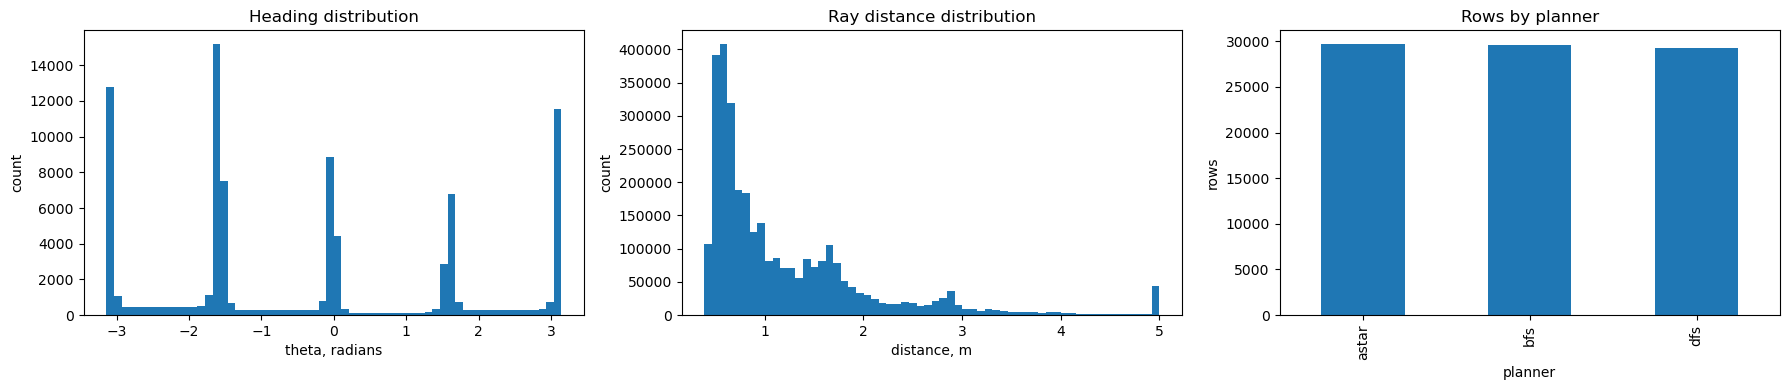

In [70]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].hist(df["theta"], bins=60)
axes[0].set_title("Heading distribution")
axes[0].set_xlabel("theta, radians")
axes[0].set_ylabel("count")

axes[1].hist(df[RAY_COLS].to_numpy().ravel(), bins=60)
axes[1].set_title("Ray distance distribution")
axes[1].set_xlabel("distance, m")
axes[1].set_ylabel("count")

df["planner"].value_counts().sort_index().plot(kind="bar", ax=axes[2])
axes[2].set_title("Rows by planner")
axes[2].set_xlabel("planner")
axes[2].set_ylabel("rows")

plt.tight_layout()
plt.show()


## 5 · Train, Validation, Test Split

We split by `maze_id`, not by random rows.

This is important because adjacent samples from the same run are highly correlated. Grouped splitting gives a more honest estimate of generalization to unseen mazes.

In [71]:
# Cell 5
# Split using the preprocessed variables from the preprocessing cell

USE_PCA_95 = False

if USE_PCA_95:
    X_features = X_raw_pca
    feature_name = "X_raw_pca"
else:
    X_features = X_raw
    feature_name = "X_raw"

theta = meta_df["theta"].to_numpy(dtype=np.float64)
y = Y.astype(np.float64)
maze_groups = meta_df["maze_id"].to_numpy()

gss_test = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=RANDOM_STATE)
train_val_idx, test_idx = next(gss_test.split(X_features, y, groups=maze_groups))

train_val_groups = maze_groups[train_val_idx]
gss_val = GroupShuffleSplit(n_splits=1, test_size=0.1875, random_state=RANDOM_STATE)
train_idx_rel, val_idx_rel = next(
    gss_val.split(X_features[train_val_idx], y[train_val_idx], groups=train_val_groups)
)

train_idx = train_val_idx[train_idx_rel]
val_idx = train_val_idx[val_idx_rel]

X_train = X_features[train_idx]
X_val = X_features[val_idx]
X_test = X_features[test_idx]

y_train = y[train_idx]
y_val = y[val_idx]
y_test = y[test_idx]

theta_train = theta[train_idx]
theta_val = theta[val_idx]
theta_test = theta[test_idx]

meta_train = meta_df.iloc[train_idx].reset_index(drop=True)
meta_val = meta_df.iloc[val_idx].reset_index(drop=True)
meta_test = meta_df.iloc[test_idx].reset_index(drop=True)

print(f"Using features: {feature_name}")
print("Train mazes:", sorted(meta_train["maze_id"].unique().tolist()))
print("Val mazes  :", sorted(meta_val["maze_id"].unique().tolist()))
print("Test mazes :", sorted(meta_test["maze_id"].unique().tolist()))
print()
print(f"Train rows: {len(X_train):,}")
print(f"Val rows  : {len(X_val):,}")
print(f"Test rows : {len(X_test):,}")

Using features: X_raw
Train mazes: ['maze_10x10_69', 'maze_10x10_rnd', 'maze_5x5_test', 'test_6x5_42']
Val mazes  : ['maze_10x10_5', 'maze_10x10_57834874']
Test mazes : ['maze_10x10_57', 'maze_5x5_rnd']

Train rows: 40,171
Val rows  : 29,597
Test rows : 18,794


## 6 · Linear Baselines and Model Selection

We standardize the training features and evaluate:
- Mean baseline
- Linear regression
- Ridge regression over a small alpha sweep

Validation performance is measured with wrapped angular error in degrees.

In [72]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)

STD_SCALER_PATH = os.path.join(MODEL_DIR, 'standard_scaler_raw.pkl')
joblib.dump(scaler, STD_SCALER_PATH)

X_val_s = scaler.transform(X_val)
X_test_s = scaler.transform(X_test)

baseline_pred_val = np.tile(y_train.mean(axis=0), (len(X_val_s), 1))
baseline_theta_val = np.arctan2(baseline_pred_val[:, 0], baseline_pred_val[:, 1])
baseline_mae_val = angle_error_deg(theta_val, baseline_theta_val).mean()

lin = LinearRegression()
lin.fit(X_train_s, y_train)
lin_pred_val = lin.predict(X_val_s)
lin_theta_val = np.arctan2(lin_pred_val[:, 0], lin_pred_val[:, 1])
lin_mae_val = angle_error_deg(theta_val, lin_theta_val).mean()

alphas = [0.01, 0.1, 1.0, 10.0, 100.0]
ridge_rows = []

for alpha in alphas:
    ridge = Ridge(alpha=alpha, random_state=RANDOM_STATE)
    ridge.fit(X_train_s, y_train)
    pred_val = ridge.predict(X_val_s)
    theta_pred_val = np.arctan2(pred_val[:, 0], pred_val[:, 1])
    mae_val = angle_error_deg(theta_val, theta_pred_val).mean()
    rmse_val = np.sqrt(np.mean(angle_error_deg(theta_val, theta_pred_val) ** 2))
    ridge_rows.append({"alpha": alpha, "mae_deg": mae_val, "rmse_deg": rmse_val})

ridge_df = pd.DataFrame(ridge_rows).sort_values("mae_deg").reset_index(drop=True)
best_alpha = float(ridge_df.loc[0, "alpha"])

print(f"Baseline val MAE, deg : {baseline_mae_val:.3f}")
print(f"Linear val MAE, deg   : {lin_mae_val:.3f}")
display(ridge_df)

Baseline val MAE, deg : 71.667
Linear val MAE, deg   : 59.586


,alpha,mae_deg,rmse_deg
0,100.00,59.584781,74.557326
1,10.00,59.586003,74.574041
2,1.00,59.586086,74.575774
3,0.10,59.586097,74.575952
4,0.01,59.586098,74.575969


## 7 · Test Set Performance for Linear Models

After choosing the best ridge penalty on the validation set, we evaluate the linear models on the held out test mazes.

This section stores:
- Predicted sin and cos values
- Recovered heading
- Per sample angular error

In [73]:
best_ridge = Ridge(alpha=best_alpha, random_state=RANDOM_STATE)
best_ridge.fit(X_train_s, y_train)

models = {
    "baseline_mean": None,
    "linear": lin,
    "ridge": best_ridge,
}

rows = []
pred_store = {}

for name, model in models.items():
    if name == "baseline_mean":
        pred_test = np.tile(y_train.mean(axis=0), (len(X_test_s), 1))
    else:
        pred_test = model.predict(X_test_s)

    theta_pred_test = np.arctan2(pred_test[:, 0], pred_test[:, 1])
    err_deg = angle_error_deg(theta_test, theta_pred_test)

    rows.append({
        "model": name,
        "mae_deg": err_deg.mean(),
        "median_deg": np.median(err_deg),
        "rmse_deg": np.sqrt(np.mean(err_deg ** 2)),
    })

    pred_store[name] = {
        "pred_xy": pred_test,
        "theta_pred": theta_pred_test,
        "err_deg": err_deg,
    }

results_df = pd.DataFrame(rows).sort_values("mae_deg").reset_index(drop=True)
display(results_df)


,model,mae_deg,median_deg,rmse_deg
0,ridge,68.819305,49.114746,85.299530
1,linear,68.845724,49.078605,85.353081
2,baseline_mean,71.595182,49.384276,83.215388


## 8 · Nonlinear Regression with MLP

A multilayer perceptron is added as a nonlinear baseline.

This tests whether heading is encoded in the ray pattern through nonlinear structure that linear models cannot capture.

In [74]:
# New cell after Cell 7
from sklearn.neural_network import MLPRegressor

mlp = MLPRegressor(
    hidden_layer_sizes=(128, 64),
    activation="relu",
    solver="adam",
    alpha=1e-4,
    batch_size=512,
    learning_rate_init=1e-3,
    max_iter=100,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=10,
    random_state=RANDOM_STATE
)

mlp.fit(X_train_s, y_train)

mlp_pred_test = mlp.predict(X_test_s)
print(X_test_s)
mlp_theta_test = np.arctan2(mlp_pred_test[:, 0], mlp_pred_test[:, 1])
mlp_err_deg = angle_error_deg(theta_test, mlp_theta_test)

results_df = pd.concat([
    results_df,
    pd.DataFrame([{
        "model": "mlp",
        "mae_deg": mlp_err_deg.mean(),
        "median_deg": np.median(mlp_err_deg),
        "rmse_deg": np.sqrt(np.mean(mlp_err_deg ** 2)),
    }])
], ignore_index=True).sort_values("mae_deg").reset_index(drop=True)

pred_store["mlp"] = {
    "pred_xy": mlp_pred_test,
    "theta_pred": mlp_theta_test,
    "err_deg": mlp_err_deg,
}

display(results_df)

# Save MLP
MLP_PATH = os.path.join(MODEL_DIR, 'mlp_model.pkl')
joblib.dump(mlp, MLP_PATH)

[[ 2.1855476   3.259135    4.6724753  ...  2.8743367  -1.4220182
  -1.456465  ]
 [ 2.1855476   3.259135    4.6724753  ...  2.8743367  -1.4220182
  -1.4564736 ]
 [ 2.1855476   3.259135    4.6724753  ...  2.8743367  -1.4219978
  -1.4513434 ]
 ...
 [ 2.1384535   1.6162207   0.06303331 ...  0.64725435  0.08960515
   0.03454432]
 [ 2.1488044   1.6418861   0.06717214 ...  0.6378292   0.08981083
   0.0390866 ]
 [ 2.1532466   1.6134375   0.06003526 ...  0.64932704  0.08990482
   0.04114807]]


/home/caballeroni7/anaconda3/envs/maze-project/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


,model,mae_deg,median_deg,rmse_deg
0,mlp,51.070846,31.806360,71.922402
1,ridge,68.819305,49.114746,85.299530
2,linear,68.845724,49.078605,85.353081
3,baseline_mean,71.595182,49.384276,83.215388


['../data/models/mlp_model.pkl']

## 9 · Direct Comparison of All Methods

We compare all methods side by side using:
- MAE
- Median error
- RMSE
- Fraction of test samples below fixed error thresholds
- Cumulative error curves

This gives a clearer picture than reporting only one best model.

In [ ]:
# Direct comparison of all current methods
# Add this right after the results_df cell

comparison_df = results_df.copy().sort_values("mae_deg").reset_index(drop=True)
display(comparison_df)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metric_cols = ["mae_deg", "median_deg", "rmse_deg"]
metric_titles = ["Mean absolute error", "Median absolute error", "RMSE"]

for ax, col, title in zip(axes, metric_cols, metric_titles):
    plot_df = comparison_df.sort_values(col)
    ax.bar(plot_df["model"], plot_df[col])
    ax.set_title(title)
    ax.set_xlabel("model")
    ax.set_ylabel("degrees")
    ax.tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

## 10 · Best Model Selection

We select the model with the lowest test MAE and use it for the remaining diagnostic plots.

The downstream analysis focuses on where the best model succeeds and where it fails.

In [ ]:
best_model_name = results_df.loc[0, "model"]
best_theta_pred = pred_store[best_model_name]["theta_pred"]
best_err_deg = pred_store[best_model_name]["err_deg"]

print(f"Best model on test: {best_model_name}")
print(f"MAE, deg         : {best_err_deg.mean():.3f}")
print(f"Median, deg      : {np.median(best_err_deg):.3f}")
print(f"RMSE, deg        : {np.sqrt(np.mean(best_err_deg ** 2)):.3f}")


## 11 · Best Model Diagnostics

For the selected best model, we inspect:
- True versus predicted heading
- Error histogram
- Error by planner
- Error by maze

This shows both average performance and failure variability.

In [ ]:
# New cell: per planner and per maze error summary for the best model

analysis_df = meta_test.copy()
analysis_df["theta_true"] = theta_test
analysis_df["theta_pred"] = best_theta_pred
analysis_df["err_deg"] = best_err_deg

planner_summary = (
    analysis_df.groupby("planner")["err_deg"]
    .agg(["count", "mean", "median", "max"])
    .sort_values("mean")
    .rename(columns={
        "count": "rows",
        "mean": "mae_deg",
        "median": "median_deg",
        "max": "max_deg"
    })
)

maze_summary = (
    analysis_df.groupby("maze_id")["err_deg"]
    .agg(["count", "mean", "median", "max"])
    .sort_values("mean")
    .rename(columns={
        "count": "rows",
        "mean": "mae_deg",
        "median": "median_deg",
        "max": "max_deg"
    })
)

print("Per planner error summary")
display(planner_summary)

print("Per maze error summary")
display(maze_summary)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

planner_summary["mae_deg"].plot(kind="bar", ax=axes[0])
axes[0].set_title(f"Mean test error by planner, {best_model_name}")
axes[0].set_xlabel("planner")
axes[0].set_ylabel("MAE, deg")
axes[0].tick_params(axis="x", rotation=0)

maze_summary["mae_deg"].plot(kind="bar", ax=axes[1])
axes[1].set_title(f"Mean test error by maze, {best_model_name}")
axes[1].set_xlabel("maze_id")
axes[1].set_ylabel("MAE, deg")
axes[1].tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.show()

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].scatter(theta_test, best_theta_pred, s=4, alpha=0.25)
axes[0, 0].plot([-np.pi, np.pi], [-np.pi, np.pi], linewidth=2)
axes[0, 0].set_title(f"True vs predicted heading, {best_model_name}")
axes[0, 0].set_xlabel("true theta, radians")
axes[0, 0].set_ylabel("pred theta, radians")

axes[0, 1].hist(best_err_deg, bins=60)
axes[0, 1].set_title("Absolute angular error")
axes[0, 1].set_xlabel("error, deg")
axes[0, 1].set_ylabel("count")

pd.Series(best_err_deg).groupby(meta_test["planner"]).mean().sort_index().plot(kind="bar", ax=axes[1, 0])
axes[1, 0].set_title("Mean test error by planner")
axes[1, 0].set_xlabel("planner")
axes[1, 0].set_ylabel("MAE, deg")

pd.Series(best_err_deg).groupby(meta_test["maze_id"]).mean().sort_values().plot(kind="bar", ax=axes[1, 1])
axes[1, 1].set_title("Mean test error by maze")
axes[1, 1].set_xlabel("maze_id")
axes[1, 1].set_ylabel("MAE, deg")

plt.tight_layout()
plt.show()


## 12 · Coefficient Inspection

For linear models, the learned weights over the 36 rays provide a direct view of which sensor directions contribute most to predicting sin(theta) and cos(theta).

This section is skipped when the best model is nonlinear.

In [ ]:
if best_model_name in ["ridge", "linear"]:
    coeff_model = best_ridge if best_model_name == "ridge" else lin

    coef_sin = coeff_model.coef_[0]
    coef_cos = coeff_model.coef_[1]

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    axes[0].plot(range(len(RAY_COLS)), coef_sin, marker="o")
    axes[0].set_title(f"{best_model_name} coefficients for sin(theta)")
    axes[0].set_xlabel("ray index")
    axes[0].set_ylabel("weight")

    axes[1].plot(range(len(RAY_COLS)), coef_cos, marker="o")
    axes[1].set_title(f"{best_model_name} coefficients for cos(theta)")
    axes[1].set_xlabel("ray index")
    axes[1].set_ylabel("weight")

    plt.tight_layout()
    plt.show()
else:
    print(f"Coefficient plot skipped for model: {best_model_name}")

## 13 · Spatial Error Analysis

We map prediction error back onto the maze geometry.

This helps identify where heading recovery is easy and where it becomes ambiguous, such as at turns, junctions, and symmetric regions.

In [ ]:
# Spatial comparison for all methods
# Full open maze is shown in light grey
# Error color scale is fixed from blue = 0 deg to red = 180 deg

target_maze = meta_test["maze_id"].value_counts().idxmax()
model_names = list(pred_store.keys())
n_models = len(model_names)

ncols = 2
nrows = int(np.ceil(n_models / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(12, 6 * nrows))
axes = np.atleast_1d(axes).ravel()

for ax, model_name in zip(axes, model_names):
    draw_maze(ax, target_maze, MAZE_DIR)

    model_plot_df = meta_test.copy()
    model_plot_df["theta_pred"] = pred_store[model_name]["theta_pred"]
    model_plot_df["err_deg"] = pred_store[model_name]["err_deg"]
    model_plot_df = model_plot_df[model_plot_df["maze_id"] == target_maze].copy()

    sc_err = ax.scatter(
        model_plot_df["x"],
        model_plot_df["y"],
        c=model_plot_df["err_deg"],
        s=14,
        alpha=0.95,
        cmap="jet",
        vmin=0,
        vmax=180,
        zorder=2
    )

    ax.set_title(f"{model_name} error, {target_maze}")
    ax.set_xlabel("x, m")
    ax.set_ylabel("y, m")
    ax.set_aspect("equal")

for j in range(len(model_names), len(axes)):
    axes[j].axis("off")

fig.subplots_adjust(right=0.88, wspace=0.25, hspace=0.30)
cbar_ax = fig.add_axes([0.90, 0.15, 0.02, 0.70])
fig.colorbar(sc_err, cax=cbar_ax, label="absolute angular error, deg")
plt.show()

## 14 · Final Summary

This section reports:
- Split sizes
- Number of mazes per split
- Final model comparison table

It serves as a compact summary of the full supervised regression experiment.

In [ ]:
summary = pd.DataFrame({
    "split": ["train", "val", "test"],
    "rows": [len(meta_train), len(meta_val), len(meta_test)],
    "unique_mazes": [
        meta_train["maze_id"].nunique(),
        meta_val["maze_id"].nunique(),
        meta_test["maze_id"].nunique(),
    ],
})

display(summary)
display(results_df)

print("Done.")


In [ ]:
import joblib
from pathlib import Path

EXPORT_DIR = Path("artifacts")
EXPORT_DIR.mkdir(exist_ok=True)

joblib.dump(
    {
        "model_name": best_model_name,
        "model": mlp if best_model_name == "mlp" else (best_ridge if best_model_name == "ridge" else lin),
        "scaler": scaler,
        "ray_cols": RAY_COLS,
        "random_state": RANDOM_STATE,
        "target": "heading via sin(theta), cos(theta)",
        "notes": "Input rays kept in robot frame. Output recovered with atan2."
    },
    EXPORT_DIR / "heading_model.joblib"
)

print("Saved:", EXPORT_DIR / "heading_model.joblib")

In [ ]:
midterm_sup = pd.DataFrame({
    "Model":            ["Baseline mean", "Linear regression", "Ridge regression", "MLP regressor"],
    "MAE (midterm)":    [71.19, 57.88, 57.88, 26.32],
    "Median (midterm)": [46.13, 47.81, 47.81,  7.81],
    "RMSE (midterm)":   [82.54, 72.46, 72.46, 53.65],
})

# Pull from results_df by model name
r = results_df.set_index("model")
midterm_sup["MAE (augmented)"]    = [r.loc["baseline_mean","mae_deg"], r.loc["linear","mae_deg"], r.loc["ridge","mae_deg"], r.loc["mlp","mae_deg"]]
midterm_sup["Median (augmented)"] = [r.loc["baseline_mean","median_deg"], r.loc["linear","median_deg"], r.loc["ridge","median_deg"], r.loc["mlp","median_deg"]]
midterm_sup["RMSE (augmented)"]   = [r.loc["baseline_mean","rmse_deg"], r.loc["linear","rmse_deg"], r.loc["ridge","rmse_deg"], r.loc["mlp","rmse_deg"]]

midterm_sup["MAE % Δ"]    = ((midterm_sup["MAE (augmented)"]    - midterm_sup["MAE (midterm)"])    / midterm_sup["MAE (midterm)"]    * 100).round(1)
midterm_sup["Median % Δ"] = ((midterm_sup["Median (augmented)"] - midterm_sup["Median (midterm)"]) / midterm_sup["Median (midterm)"] * 100).round(1)
midterm_sup["RMSE % Δ"]   = ((midterm_sup["RMSE (augmented)"]   - midterm_sup["RMSE (midterm)"])   / midterm_sup["RMSE (midterm)"]   * 100).round(1)

print(midterm_sup.to_string(index=False))